<a href="https://colab.research.google.com/github/ananyab123/bioinformatics/blob/main/InformaticsMIMICDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use the MIMIC dataset to conduct real-world analysis.

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Load sample MIMIC data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
admissions_data = pd.read_csv('/content/drive/MyDrive/ADMISSIONS.csv')
icd_data = pd.read_csv('/content/drive/MyDrive/DIAGNOSES_ICD.csv')

#Merge the two datasets on patient_id and summarize the patient characteristics


In [6]:
admissions_data.shape, icd_data.shape

((129, 19), (1761, 5))

In [7]:
# not a bunch of nans, which is cool. 94.5% of cells have good values.
data = admissions_data.merge(icd_data, on="subject_id", suffixes=("_admit", "_icd"))
data.isna().sum().sum() / (data.shape[0] * data.shape[1])

np.float64(0.05471306685366994)

The [documentation for MIMIC-III][docs] says `subject_id` is the patient, while `hadm_id` is the hospital admissions, which could have issues if you have a patient that's checked into different hospitals overtime e.g. recurrence, different illness, or transfer


[docs]: https://mimic.mit.edu/docs/iii/tables/

In [8]:
data["admission_type"].value_counts()

,count
admission_type,
EMERGENCY,5841
ELECTIVE,93
URGENT,18


In [9]:
def summarizing():
  """Summarizing 3 categorical variables"""
  summaries = [
      admissions_data['language'].value_counts(),
      admissions_data['marital_status'].value_counts(),
      admissions_data['religion'].value_counts(),
  ]
  for summary in summaries:
    display(summary)

summarizing()

,count
language,
ENGL,58
SPAN,16
RUSS,5
POLI,1
MAND,1


,count
marital_status,
MARRIED,60
SINGLE,26
WIDOWED,15
DIVORCED,6
UNKNOWN (DEFAULT),5
SEPARATED,1


,count
religion,
CATHOLIC,59
NOT SPECIFIED,19
UNOBTAINABLE,19
PROTESTANT QUAKER,10
JEWISH,10
OTHER,4
CHRISTIAN SCIENTIST,3
MUSLIM,2
BUDDHIST,1


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   row_id_admit          5952 non-null   int64 
 1   subject_id            5952 non-null   int64 
 2   hadm_id_admit         5952 non-null   int64 
 3   admittime             5952 non-null   object
 4   dischtime             5952 non-null   object
 5   deathtime             630 non-null    object
 6   admission_type        5952 non-null   object
 7   admission_location    5952 non-null   object
 8   discharge_location    5952 non-null   object
 9   insurance             5952 non-null   object
 10  language              5254 non-null   object
 11  religion              5943 non-null   object
 12  marital_status        5789 non-null   object
 13  ethnicity             5952 non-null   object
 14  edregtime             5303 non-null   object
 15  edouttime             5303 non-null   

In [11]:
data["admission_type"].value_counts()

,count
admission_type,
EMERGENCY,5841
ELECTIVE,93
URGENT,18


In [13]:
def extract_length_of_hospital_stay(df_admissions: pd.DataFrame) -> pd.Series:
  dt_diff = (pd.to_datetime(df_admissions['dischtime']) - pd.to_datetime(df_admissions['admittime']))
  floating_days = dt_diff.dt.total_seconds() / (24 * 3600)
  return floating_days

def extract_length_of_ed_stay(df_admissions: pd.DataFrame) -> pd.Series:
  dt_diff = (pd.to_datetime(df_admissions['edouttime']) - pd.to_datetime(df_admissions['edregtime']))
  floating_days = dt_diff.dt.total_seconds() / (24 * 3600)
  return floating_days


def createNewVariables(coerce=True):
  """Create 2 new variables called `length_of_ed_stay` and `length_of_hospital_stay` using the mimic data

  Arguments:
    coerce: fill-in the missing ED durations with the duration of the hospital stay
  """
  data['length_of_hospital_stay'] = extract_length_of_hospital_stay(data)

  measured_ed_stay_where_valid = extract_length_of_ed_stay(data)
  data['has_true_ed_duration'] = measured_ed_stay_where_valid.isna() == False
  assert (data['has_true_ed_duration'].sum() == (data.shape[0] - data["edregtime"].isna().sum() )), "true ED count != real ed count"
  if coerce:
    # take the hospital stay wherever the ED stay isn't there
    data['length_of_ed_stay'] = (
      measured_ed_stay_where_valid.combine_first(data['length_of_hospital_stay'])
    )
  else:
    data['length_of_ed_stay'] = measured_ed_stay_where_valid
  display(data.head())

createNewVariables()


,row_id_admit,subject_id,hadm_id_admit,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,...,diagnosis,hospital_expire_flag,has_chartevents_data,row_id_icd,hadm_id_icd,seq_num,icd9_code,length_of_hospital_stay,has_true_ed_duration,length_of_ed_stay
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,112344,142345,1,99591,8.8375,True,0.261806
1,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,112345,142345,2,99662,8.8375,True,0.261806
2,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,112346,142345,3,5672,8.8375,True,0.261806
3,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,112347,142345,4,40391,8.8375,True,0.261806
4,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,...,SEPSIS,0,1,112348,142345,5,42731,8.8375,True,0.261806


<Axes: ylabel='Density'>

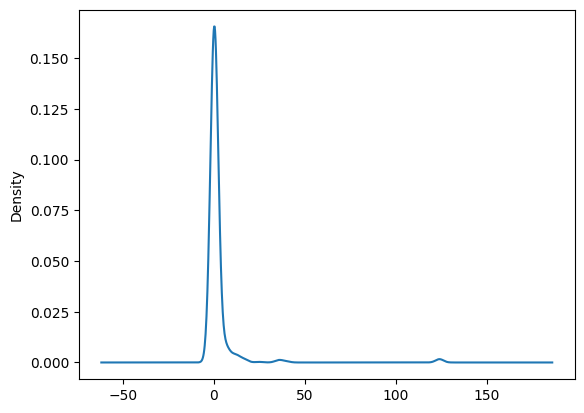

In [14]:
data['length_of_ed_stay'].plot.density()

<Axes: ylabel='Frequency'>

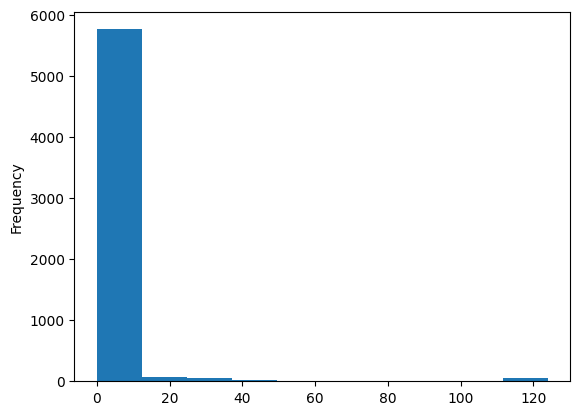

In [15]:
data['length_of_ed_stay'].plot.hist()

We note with the prevalance calculations below that there's an absence of ED registration data for a meaningful chunk of the admits (~600 people). It doesn't come up heavily in the analysis we chose, but it should be considered in other work.

In [16]:
# percent visited the ED
data["edregtime"].isna().sum() / data.shape[0]

np.float64(0.10903897849462366)

In [17]:
data["edouttime"].isna().sum() / data.shape[0]

np.float64(0.10903897849462366)

In [18]:
data["admission_type"].value_counts() / data.shape[0]

,count
admission_type,
EMERGENCY,0.981351
ELECTIVE,0.015625
URGENT,0.003024


In [19]:
# how many we're missing, exactly.
data["admission_type"].value_counts()["EMERGENCY"] - data['has_true_ed_duration'].sum()

np.int64(538)

In [20]:
# initially finding the length of ed_stay be HEAVILY 0, I switched the implementation to using fractions of days
# it makes the summary more interesting.
data[["length_of_ed_stay", "length_of_hospital_stay"]].describe()

,length_of_ed_stay,length_of_hospital_stay
count,5952.000000,5952.000000
mean,2.370640,7.955962
std,12.322010,12.340183
min,0.054167,0.038194
25%,0.165278,2.941667
50%,0.209028,5.252083
75%,0.318056,8.614583
max,123.984722,123.984722


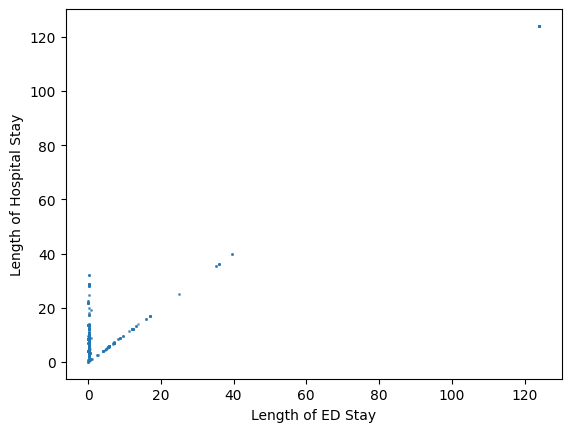

In [21]:
plt.scatter(
    data['length_of_ed_stay'],
    data['length_of_hospital_stay'],
    alpha=0.1,
    s=1,
)
plt.xlabel("Length of ED Stay")
plt.ylabel("Length of Hospital Stay")
plt.show()

No meaningful relationship, but there's a clustering in the lower lefthand corner.

In [22]:
def crude_parse_icd9(icd9_code: str) -> tuple[str, str]:
  """Parse an ICD9 code into a major and minor code"""
  return (icd9_code[:3], icd9_code[3:])

In [23]:
data[['icd_major_code', 'icd_minor_code']] = data['icd9_code'].apply(crude_parse_icd9).apply(pd.Series)

<Axes: ylabel='icd_major_code'>

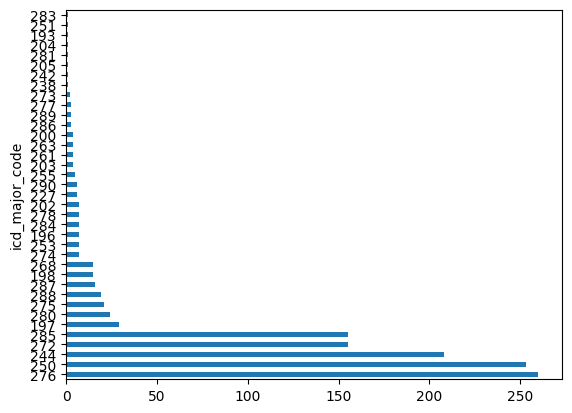

In [24]:
data["icd_major_code"][data["icd_major_code"].between("190", "290")].value_counts().plot.barh()

In [25]:
# (pre filtering)
# 191 -> brain cancer
# 196 -> secondary lymphaic cancer
# 214 -> lipoma
# (post i.e. most interesting thing with numbers)
# 244 -> ACQUIRED hypothyroidism

In [26]:
analyte = data[data["icd_major_code"] == "244"]
analyte.shape

(208, 28)

# Conduct Analysis


In [27]:

non_analytic_columns = ["hadm_id_admit", "row_id_admit", "subject_id", "row_id_icd", "hadm_id_icd", "seq_num"]
analyte.drop(columns=non_analytic_columns).describe()

,hospital_expire_flag,has_chartevents_data,length_of_hospital_stay,length_of_ed_stay
count,208.000000,208.0,208.000000,208.000000
mean,0.038462,1.0,5.779581,0.258654
std,0.192772,0.0,3.612924,0.520980
min,0.000000,1.0,1.679861,0.059722
25%,0.000000,1.0,2.923611,0.165278
50%,0.000000,1.0,4.080556,0.196528
75%,0.000000,1.0,7.351389,0.233333
max,1.000000,1.0,28.938194,5.688194


In [28]:
analyte['discharge_location'].value_counts()

,count
discharge_location,
SNF,146
ICF,39
LONG TERM CARE HOSPITAL,13
DEAD/EXPIRED,8
REHAB/DISTINCT PART HOSP,1
HOME HEALTH CARE,1


In [29]:
percent_deceased = 1 - analyte['deathtime'].isna().sum() / analyte.shape[0]
print(f"Deceased: {percent_deceased:.2%}")

Deceased: 3.85%


Given the lack of lethality of the disease (3.85% for hypothyroidism), we're really splitting hairs here.

N = 8 isn't predictive of much, but we'll do the analysis anyway.

### Is mortality predicted by length of stay?

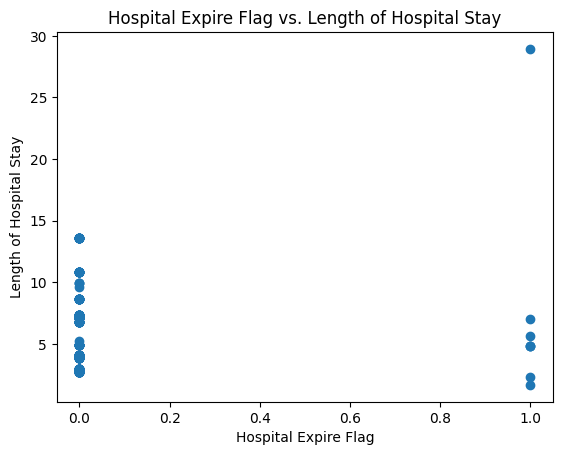

In [30]:
fig, ax = plt.subplots()
ax.scatter(analyte['hospital_expire_flag'], analyte['length_of_hospital_stay'])
ax.set_xlabel("Hospital Expire Flag")
ax.set_ylabel("Length of Hospital Stay")
ax.set_title("Hospital Expire Flag vs. Length of Hospital Stay")
fig.show()

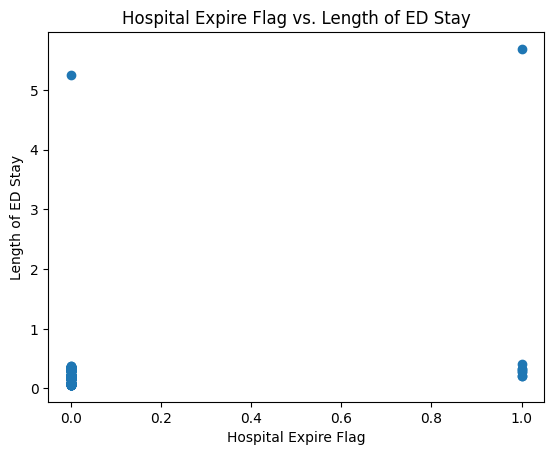

In [31]:
fig, ax = plt.subplots()
ax.scatter(analyte['hospital_expire_flag'], analyte['length_of_ed_stay'])
ax.set_xlabel("Hospital Expire Flag")
ax.set_ylabel("Length of ED Stay")
ax.set_title("Hospital Expire Flag vs. Length of ED Stay")
fig.show()

Doesn't look very preditive. Let's double check the numbers

In [32]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.stats.anova as anova

In [33]:
analyte['icd_minor_code'].value_counts()

,count
icd_minor_code,
9,208


This is "UNSPECIFIED Acquired Hypothyroidism"

In [35]:
sms.anova_lm(smf.ols('hospital_expire_flag ~ length_of_hospital_stay', data=analyte).fit())

,df,sum_sq,mean_sq,F,PR(>F)
length_of_hospital_stay,1.0,0.071393,0.071393,1.929822,0.166278
Residual,206.0,7.620914,0.036995,NaN,NaN


We fail to reject the null in the hospital case.

If we were to expand this project, I could leverage my machine learning background and present similar with a one-class classifier (given the huge class imbalance).

In [36]:
sms.anova_lm(smf.ols('hospital_expire_flag ~ length_of_ed_stay', data=analyte).fit())

,df,sum_sq,mean_sq,F,PR(>F)
length_of_ed_stay,1.0,0.570877,0.570877,16.513633,0.000069
Residual,206.0,7.121431,0.034570,NaN,NaN


We reject the null hypothesis, i.e. staying in the ED does predict the fatal outcome for this dataset

In [38]:
anova.anova_lm(smf.ols(formula='hospital_expire_flag ~ C(admission_type)', data=analyte).fit())

,df,sum_sq,mean_sq,F,PR(>F)
C(admission_type),2.0,0.930172,0.465086,14.099481,0.000002
Residual,205.0,6.762136,0.032986,NaN,NaN


We reject the null here for the question "Is mortality predicted by admission type", as well, but that's not a profound finding.
Why? Because of the following:

In [37]:
analyte['admission_type'].value_counts()

,count
admission_type,
EMERGENCY,206
URGENT,1
ELECTIVE,1


That is, almost all of the data set is emergency. It's like asking
> Can you predict 1 given any input?

you'll be correct 206/208 = 99% of the time

## Conclusion

Your time in the ED is predictive of your adverse outcomes. That makes sense, in a way, because the emergency department sees more acuity than standard outpatient care.
But there are confounders that are harder to look at when it comes to emergency care that we can't see with this data
* How long have they had this condition?
* Did the providers ever reach a clear root cause?
* Were there additional contributors (e.g. immune deficiency disorders) to the disease i.e. acquired hypothyroidism?


There is more investigative work that could be done here.

This exploration has shown me the interesting clinican questions we can start to answer, the models we can start to build, and the potential for further work to improving patient outcomes.